In [6]:
using Revise
using Optics_in_the_length_gauge
using LinearAlgebra
using Parameters
using Field_Induced_Hall_Effect
using Brillouin
using Bravais
using CairoMakie, BZpaths

In [7]:
pathof(Optics_in_the_length_gauge)

"/Users/fernandopenaranda/.julia/packages/Optics_in_the_length_gauge/QbsqU/src/Optics_in_the_length_gauge.jl"

## Bands

In [10]:

function bands(q, p, i)
    mat = ferroaxial_ham3d(q,p.μ,p.Δ,p.t, p.tp)
    ϵs, ψs = eigen(mat)   
    return ϵs[i]
end

function bands_ferroaxial(p; a = 1)
    Rs = (a .* [1.0, 0, 0], a .* [-1/2, √3/2,0], a .* [0,0,1.0])  # Lattice vectors
    sgnum = 143                           # point group (144 = p3_1)
    N = 200    #kpoints
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]", title = "Δ = $(p.Δ) eV, t = $(p.t) eV, tp = $(p.tp) eV")
    for i in 1:2
        dispersion(q) = bands(q, p, i)
        BZpaths.plot_observable_in_kpath!(ax, dispersion, Rs, sgnum, N)#, high_sym_line high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A] )
    end
    fig
end

bands_ferroaxial (generic function with 1 method)

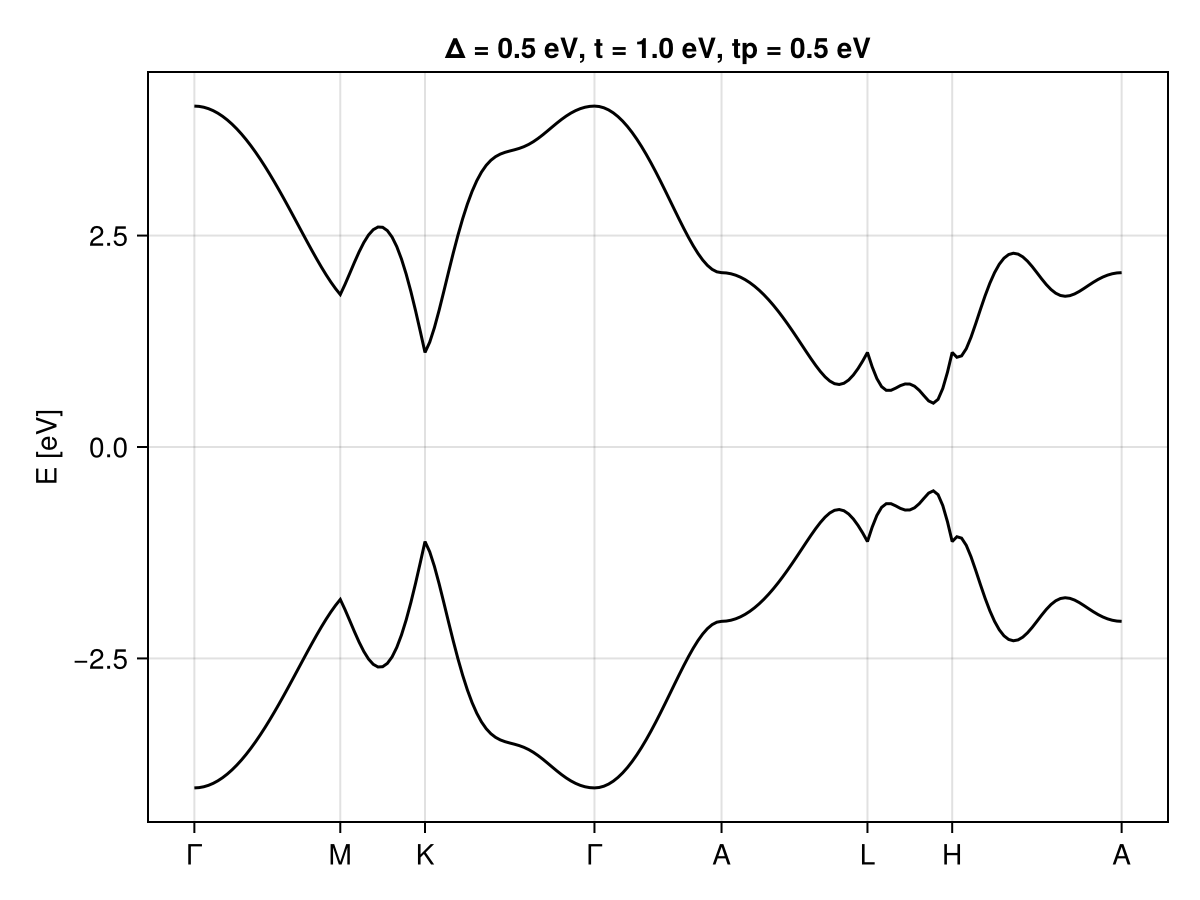

In [11]:
bands_ferroaxial( modelpresets_FA(; μ =0, t =1 ,tp =0.5, Δ = 0.5))

## Calculations

In [12]:
evals = 160000
mu = 1.6152778733409938
murange = collect(-3:0.5:3)
xbounds = [-0.5,-0.5, -0.5]
T = 5

kws = (dirj = :x, dirE = :y, dirB = :x, T = T,
    evals = evals, integration_method = :montecarlo, fermi_surface = true, botbounds =xbounds, 
    topbounds = -xbounds, Ω_MM_switch = false, PS_switch = true, QM_switch = true)
#_________________________________________________________________________________________



(dirj = :x, dirE = :y, dirB = :x, T = 5, evals = 160000, integration_method = :montecarlo, fermi_surface = true, botbounds = [-0.5, -0.5, -0.5], topbounds = [0.5, 0.5, 0.5], Ω_MM_switch = false, PS_switch = true, QM_switch = true)

In [14]:
p = modelpresets_FA(; μ = 2, t = 1 ,tp = 0.5, Δ = 1)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...)
σ_ijk_A1_qc =  quantum_contribution(comp_pres) #22.1 #15 # 17

Montecarlo integration


17.946781840063966